# Transformers desde (casi) cero

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cam2149/icesi-nlp/blob/Entrega3/Sesion3/Entrega3.ipynb)

En este notebook implementaremos un clasificador de reseñas en español utilizando transformers. Implementaremos parte de la arquitectura del modelo pieza por pieza para ver como funciona por dentro. Sin embargo, utilizarémos las utilidades de tokenización de huggingface transformers para ayudarnos con esta tarea.

#### Referencias
- Dataset: https://huggingface.co/datasets/MarcOrfilaCarreras/spanish-news
- [Attention is All You Need](http://arxiv.org/abs/1706.03762)
- [Natural Language Processing with Transformers: Building Language Applications With Hugging Face](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)
- [Tutorial 5: Transformers and Multi-Head Attention](https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/05-transformers-and-MH-attention.html)

##1. Configuración e Instalación

In [57]:
# Ahora vamos a crear nuestro implementación de clasificador de reseñas de Amazon en español
# Basándonos en la estructura del archivo adjunto pero adaptándolo para el dataset de Amazon

# Primero instalamos las dependencias necesarias
import sys
import subprocess

def install_packages():
    packages = [
        'torch',
        'transformers',
        'datasets',
        'tokenizers',
        'scikit-learn',
        'matplotlib',
        'seaborn',
        'optuna',
        'pandas',
        'numpy',
        'tqdm',
        'os',
        're'
    ]

    for package in packages:
        try:
            __import__(package)
            print(f"✓ {package} ya está instalado")
        except ImportError:
            print(f"Instalando {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_packages()



✓ torch ya está instalado
✓ transformers ya está instalado
✓ datasets ya está instalado
✓ tokenizers ya está instalado
Instalando scikit-learn...
✓ matplotlib ya está instalado
✓ seaborn ya está instalado
✓ optuna ya está instalado
✓ pandas ya está instalado
✓ numpy ya está instalado
✓ tqdm ya está instalado
✓ os ya está instalado
✓ re ya está instalado


##1.1. Importación de Librerías

In [58]:
# Importaciones principales
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import optuna
import pandas as pd
import pkg_resources
import random
import re
import seaborn as sns
import subprocess
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import warnings

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from transformers.models.gpt2.tokenization_gpt2 import bytes_to_unicode
from typing import Optional, Tuple

warnings.filterwarnings('ignore')

print("Dependencias cargadas correctamente")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Número de GPUs: {torch.cuda.device_count() if torch.cuda.is_available() else 0}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo seleccionado: {device}")


Dependencias cargadas correctamente
PyTorch version: 2.8.0+cu126
CUDA disponible: False
Número de GPUs: 0
Dispositivo seleccionado: cpu


In [59]:
# Ignorar advertencias para evitar que el output se llene de mensajes innecesarios
warnings.filterwarnings("ignore")

# Desactivar el paralelismo en los tokenizadores de Hugging Face para evitar conflictos
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Ignorar advertencias (repetido para asegurar que todas las advertencias sean ignoradas)
warnings.filterwarnings('ignore')

# Función para establecer una semilla y garantizar la reproducibilidad de los resultados
def set_seed(seed):
    torch.manual_seed(seed)  # Semilla para PyTorch en la CPU
    torch.cuda.manual_seed_all(seed)  # Semilla para PyTorch en todas las GPUs
    np.random.seed(seed)  # Semilla para NumPy
    random.seed(seed)  # Semilla para el módulo random de Python
    torch.backends.cudnn.deterministic = True  # Hacer que las operaciones de cuDNN sean deterministas
    torch.backends.cudnn.benchmark = False  # Desactivar el benchmarking de cuDNN para mejorar la reproducibilidad

# Establecer la semilla en 42 para garantizar resultados reproducibles
set_seed(42)

# Crear una lista de todos los paquetes instalados en el entorno actual
installed_packages = [package.key for package in pkg_resources.working_set]

# Verificar si el código se está ejecutando en Google Colab
IN_COLAB = 'google-colab' in installed_packages


In [60]:
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

### Cargando el dataset
Este es un dataset pequeño de reseñas de productos en español con sus respectivas categorías. El dataset está disponible en el HuggingFace Hub y puede ser fácilmente descargado con la librería.

In [61]:
# Cargar dataset
from datasets import load_dataset

def load_spanish_news_dataset_train():
    """Carga el dataset de reseñas en español"""
    return load_dataset("neonwatty/amazon_reviews_multi", "es", split='train')

# 2. Cargar el dataset_test
def load_spanish_news_dataset_test():
    """Carga el dataset de reseñas en español"""
    return load_dataset("neonwatty/amazon_reviews_multi", "es", split='test')

# 3. Cargar el dataset de validación
def load_spanish_news_dataset_valid():
    """Carga el dataset de reseñas en español"""
    return load_dataset("neonwatty/amazon_reviews_multi", "es", split='validation')

print("Cargando dataset de entrenamiento...")
dataset = load_spanish_news_dataset_train()
dataset = dataset.shuffle(seed=42)

print("Cargando dataset de test...")
dataset_test = load_spanish_news_dataset_test()
dataset_test = dataset_test.shuffle(seed=42)

print("Cargando dataset de validación...")
dataset_valid = load_spanish_news_dataset_valid()
dataset_valid = dataset_valid.shuffle(seed=42)

# Acceder a un ejemplo de la división de entrenamiento
print("Observando un ejemplo del dataset:")
example = dataset[0]
print(example)

Cargando dataset de entrenamiento...
Cargando dataset de test...
Cargando dataset de validación...
Observando un ejemplo del dataset:
{'review_title': '.', 'review_body': 'La montarlo se rompió una rueda debido a materiales débiles, pero al arreglarla funciona correctamente.', 'review_id': 'es_0614019', 'stars': 3}


In [62]:
print(dataset)

Dataset({
    features: ['review_title', 'review_body', 'review_id', 'stars'],
    num_rows: 200000
})


Para los efectos de esta tarea, nos servirán el review_title y review_body naturalmente.

A manera general, observemos que tan largos o cortos tienden a ser los textos.

In [63]:
%%time
from datasets import load_dataset

# Load all splits of the dataset
print("Cargando datasets (train, test, validation)...")
dataset_splits = {
    'train': dataset,
    'test': dataset_test,
    'validation': dataset_valid
}
print("Datasets cargados.")

def analyze_text_lengths(dataset_split, split_name):
    """Calcula y muestra las longitudes de texto para un split del dataset."""
    print(f"\nAnalizando longitudes de texto para el split: {split_name}")

    # Calculate lengths for both 'review_title' and 'review_body' and combine them
    text_lengths = [len(row['review_title']) + len(row['review_body']) for row in dataset_split]

    if text_lengths:
        print(f"Texto más corto: {min(text_lengths)}")
        print(f"Texto más largo: {max(text_lengths)}")
        print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths):.2f}")
    else:
        print("No hay datos en este split para analizar.")

# Analyze each split
for split_name, dataset_split in dataset_splits.items():
    analyze_text_lengths(dataset_split, split_name)

Cargando datasets (train, test, validation)...
Datasets cargados.

Analizando longitudes de texto para el split: train
Texto más corto: 20
Texto más largo: 3160
Longitud promedio: 170.47

Analizando longitudes de texto para el split: test
Texto más corto: 22
Texto más largo: 1816
Longitud promedio: 171.08

Analizando longitudes de texto para el split: validation
Texto más corto: 22
Texto más largo: 1616
Longitud promedio: 169.40
CPU times: user 31 s, sys: 54.8 ms, total: 31.1 s
Wall time: 43.4 s


Estos valores son la cantidad de caractéres que tiene las secuencias. Una decisión ingenua pero útil en este momento podría ser ajustar la longitud de las secuencias que vamos a usar para el entrenamiento a unos 2000 tokens. Esto podría ser suficiente para capturar una porción significativa de los textos.

##2. Preprocesamiento de Datos
Cargamos y preprocesamos el dataset para que sea adecuado para el entrenamiento.

##2.2. Limpieza de Texto y Tokenización
Implementamos una función de limpieza para eliminar ruido del texto. Luego, usamos un tokenizador de Hugging Face para convertir el texto en secuencias de tokens.

In [64]:
# Función de limpieza de texto
def clean_text(text):
    text = re.sub(r'<[^>]+>', '', text)  # Eliminar etiquetas HTML
    text = re.sub(r'https?://\S+', '', text)  # Eliminar URLs
    text = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑüÜ\s]', '', text)  # Eliminar caracteres especiales y números
    text = text.lower()  # Convertir a minúsculas
    return text

def preprocess_text(text):
    return text.lower().replace("<br />", " ").strip()

In [65]:
%%time
# Aplicar la limpieza de texto a las reseñas
dataset = dataset.map(lambda example: {'review_body': preprocess_text(example['review_body'])})
dataset_valid = dataset_valid.map(lambda example: {'review_body': preprocess_text(example['review_body'])})
dataset_test = dataset_test.map(lambda example: {'review_body': preprocess_text(example['review_body'])})

CPU times: user 24 ms, sys: 1.97 ms, total: 26 ms
Wall time: 50.1 ms


In [66]:
%%time
# Aplicar la limpieza de texto a las reseñas
dataset = dataset.map(lambda example: {'review_body': clean_text(example['review_body'])})
dataset_valid = dataset_valid.map(lambda example: {'review_body': clean_text(example['review_body'])})
dataset_test = dataset_test.map(lambda example: {'review_body': clean_text(example['review_body'])})

CPU times: user 27 ms, sys: 1.99 ms, total: 28.9 ms
Wall time: 52 ms


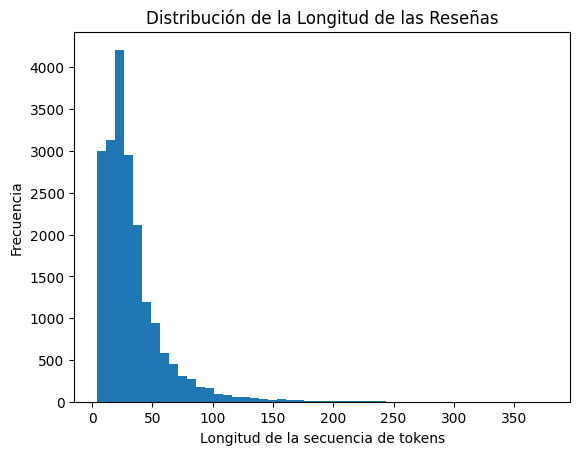

CPU times: user 10 s, sys: 19.3 ms, total: 10 s
Wall time: 13.2 s


In [67]:
%%time
from datasets import load_dataset

# Select a subset of the dataset for analysis by shuffling and taking the first sample_size elements
sample_size = 20000
# Shuffle the dataset and select the first 'sample_size' elements
dataset_shuffled = dataset.shuffle(seed=42)
df_sample = dataset_shuffled.select(range(sample_size))

# Analizar la distribución de la longitud de las reseñas para determinar max_len
# Ensure 'review_body' is accessible as a list or similar for the list comprehension
review_lengths = [len(tokenizer.encode(review, add_special_tokens=True)) for review in df_sample['review_body']]
plt.hist(review_lengths, bins=50)
plt.title('Distribución de la Longitud de las Reseñas')
plt.xlabel('Longitud de la secuencia de tokens')
plt.ylabel('Frecuencia')
plt.show()


## Definiendo el Tokenizer

Ahora, vamos a definir el tokenizer para nuestra tarea. Para ahorrarnos tiempo, vamos a entrenar uno basado en dccuchile/bert-base-spanish-wwm-cased, ajustado a nuestro dataset. Para ello, debemos seleccionar una muestra representativa de nuestro dataset, como no es muy grande, casi que podemos usarlo todo. Luego, debemos definir el tamaño del vocabulario, es decir, cuantos tokens únicos queremos soportar en nuestro tokenizador. Para que un modelo de lenguaje funcione moderadamente bien para una tarea de clasificación, considerando el tamaño de nuestro corpus, deberíamos definir unos 50 mil tokens.

In [68]:
%%time
# Inicializar el tokenizador
model_name = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Mapeo de bytes a caracteres Unicode...")
# Mapeo de bytes a caracteres Unicode: crea un diccionario que asigna cada byte a un carácter Unicode
byte_to_unicode_map = bytes_to_unicode()

# Mapeo inverso: crea un diccionario que asigna cada carácter Unicode a su byte correspondiente
unicode_to_byte_map = dict((v, k) for k, v in byte_to_unicode_map.items())

# Base del vocabulario: crea una lista con los caracteres Unicode que forman la base del vocabulario
base_vocab = list(unicode_to_byte_map.keys())
print("Crear iteradores para los conjuntos de datos: dataset, dataset_valid y dataset_test...")
# Crear iteradores para los conjuntos de datos: dataset, dataset_valid y dataset_test
iter_dataset = iter(dataset)
iter_dataset_valid = iter(dataset_valid)
iter_dataset_test = iter(dataset_test)

# Función para generar lotes (batches) de datos desde un iterador
def batch_iterator(dataset_iterator, batch_size: int = 10):
    while True:
        batch = []
        try:
            # Agregar elementos al lote hasta alcanzar el tamaño especificado
            for _ in range(batch_size):
                batch.append(next(dataset_iterator)['review_body'])
            yield batch  # Devolver el lote completo
        except StopIteration:
            # Si se alcanza el final del iterador, devolver el último lote y salir
            if batch:
                yield batch
            break

# Entrenar un nuevo tokenizador usando el iterador de lotes para el conjunto de datos principal
# vocab_size: tamaño del vocabulario (50,000 en este caso)
# initial_alphabet: caracteres base del vocabulario
print(" Entrenar un nuevo tokenizador usando el iterador de lotes para el conjunto de datos principal")
spanish_news_tokenizer = tokenizer.train_new_from_iterator(batch_iterator(iter_dataset), vocab_size=50000, initial_alphabet=base_vocab)

# Entrenar un nuevo tokenizador para el conjunto de datos de validación
# vocab_size: tamaño del vocabulario basado en el tamaño del conjunto de validación
print(" Entrenar un nuevo tokenizador para el conjunto de datos de validación")
spanish_news_tokenizer_val = tokenizer.train_new_from_iterator(batch_iterator(iter_dataset_valid), vocab_size=len(dataset_valid), initial_alphabet=base_vocab)

# Entrenar un nuevo tokenizador para el conjunto de datos de prueba
# vocab_size: tamaño del vocabulario basado en el tamaño del conjunto de prueba
print(" Entrenar un nuevo tokenizador para el conjunto de datos de prueba")
spanish_news_tokenizer_test = tokenizer.train_new_from_iterator(batch_iterator(iter_dataset_test), vocab_size=len(dataset_test), initial_alphabet=base_vocab)


Mapeo de bytes a caracteres Unicode...
Crear iteradores para los conjuntos de datos: dataset, dataset_valid y dataset_test...
 Entrenar un nuevo tokenizador usando el iterador de lotes para el conjunto de datos principal
 Entrenar un nuevo tokenizador para el conjunto de datos de validación
 Entrenar un nuevo tokenizador para el conjunto de datos de prueba
CPU times: user 30.8 s, sys: 28.7 ms, total: 30.9 s
Wall time: 36.1 s


In [69]:
tokens = sorted(spanish_news_tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)
print(f"Vocabulario: {spanish_news_tokenizer.vocab_size} tokens")
print("Primeros 15 tokens:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[1000:1015]])
print("Últimos 15 tokens:")
print([f"{spanish_news_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Vocabulario: 50000 tokens
Primeros 15 tokens:
['[MASK]', '[PAD]', '[UNK]', '[CLS]', '[SEP]', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*']
15 tokens de en medio:
['tras', 'sea', '##jas', 'can', '##tras', '##ren', '##dí', 'vis', 'espa', 'poder', '##ban', 'diseño', 'pod', 'tienes', 'mí']
Últimos 15 tokens:
['pómez', 'pómulos', 'polaca', 'scaner', 'scanear', 'wmv', 'worten', 'wilson', 'williams', '##stone', '##utsche', 'escarmentado', 'esceptica', 'untuoso', 'untuosidad']


Vemos que los primeros tokens corresponden a caracteres especiales y puntiación. Luego en el medio tenemos una combinación entre palabras completas y cortadas, el tokenizador se encarga de encontrar las frecuencias más comunes y asi partir las palabras por aquellas partes que tienden a repetirse mas. Esto es muy útil para trabajar con modelos de lenguaje ya que el modelo se vuelve robusto a diferentes ramificaciones de palabras e incluso a errores de tipografía. Finalmente, al final, vemos que tenemos más palabras cortadas y palabras muy especiales. Algo importante aquí es que podamos ver que los tokens tienen sentido con respecto a nuestro corpus.

Ahora veamos como convierte el tokenizador una oración muy sencilla:

In [70]:
spanish_news_tokenizer.pad_token = '[PAD]'
spanish_news_tokenizer("hola mundo!", max_length=8, truncation=True, padding='max_length')

{'input_ids': [3, 2202, 2387, 5, 4, 1, 1, 1], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 0, 0, 0]}

In [71]:
spanish_news_tokenizer("hola mundo!", max_length=8, truncation=True, padding='max_length').tokens()

['[CLS]', 'hola', 'mundo', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]']

In [72]:
import torch
import numpy as np
from typing import Tuple, Dict
from torch.utils.data import Dataset

# Dataset personalizado
class SpanishNewsDataset(Dataset):
    # El constructor inicializa el dataset personalizado.
    # Recibe un tokenizador (función), el dataset original de Hugging Face y la longitud máxima de secuencia.
    def __init__(self, tokenizer, dataset, seq_length: int = 128):
        # Almacena el tokenizador, el dataset original y la longitud máxima.
        self.tokenizer = tokenizer
        self.dataset = dataset
        self.seq_length = seq_length
        # Definimos estos dos mapas para facilitarnos la tarea
        # de traducir de nombres de categoría a ids de categoría.
        # id_2_class_map: Mapea IDs numéricos (0, 1, 2, 3, 4) a las clases originales de estrellas (1, 2, 3, 4, 5).
        self.id_2_class_map = dict(enumerate(np.unique(dataset[:]['stars'])))
        # class_2_id_map: Mapea las clases originales de estrellas (1, 2, 3, 4, 5) a IDs numéricos (0, 1, 2, 3, 4).
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        # Almacena el número total de clases (5 en este caso).
        self.num_classes = len(self.id_2_class_map)
        # Get the UNK token ID from the tokenizer
        self.unk_token_id = self.tokenizer.unk_token_id


    # Este método es fundamental para PyTorch Datasets y define cómo obtener un elemento individual.
    # Recibe un índice y devuelve un diccionario con los datos de entrada y la etiqueta.
    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        # Obtiene el texto de la reseña y la calificación de estrellas del dataset original por índice.
        text, y = self.dataset[index]['review_body'], self.dataset[index]['stars']
        # Convierte la calificación de estrellas a su ID numérico usando el mapa.
        y = self.class_2_id_map[y]
        # Tokeniza el texto de la reseña, limita la longitud y obtiene the encoding object
        encoding = self.tokenizer(text, max_length=self.seq_length, padding='max_length', truncation=True)

        # Convert encoding components to NumPy arrays before creating tensors
        input_ids_np = np.array(encoding['input_ids'])
        attention_mask_np = np.array(encoding['attention_mask'])

        # Create tensors
        input_ids_tensor = torch.tensor(input_ids_np, dtype=torch.long)
        attention_mask_tensor = torch.tensor(attention_mask_np, dtype=torch.long)
        y_tensor = torch.tensor(y, dtype=torch.long)

        # Check for and replace out-of-range token IDs with UNK token ID directly on the tensor
        vocab_size = self.tokenizer.vocab_size
        input_ids_tensor[input_ids_tensor >= vocab_size] = self.unk_token_id


        data = {
            'input_ids': input_ids_tensor,
            'attention_mask': attention_mask_tensor,
            'y': y_tensor
        }

        # Devuelve el diccionario con los datos preparados.
        return data

    # Este método es requerido para PyTorch Datasets y devuelve el número total de elementos en el dataset.
    def __len__(self):
        # Retorna la longitud del dataset original.
        return len(self.dataset)

In [73]:
max_len = 2048

# Assuming dataset_splits contains the loaded train, test, and validation datasets
if 'dataset_splits' in globals():
    for split_name, dataset_split in dataset_splits.items():
        print(f"\nCreando y verificando Dataset personalizado para el split: {split_name}")
        try:
            spanish_news_dataset = SpanishNewsDataset(spanish_news_tokenizer, dataset_split, seq_length=max_len)
            assert len(spanish_news_dataset) == len(dataset_split)
            print(f"✓ Dataset personalizado '{split_name}' creado con éxito y longitud verificada.")
        except AssertionError:
            print(f"Dataset personalizado '{split_name}' creado, la longitud verificada no es correcta.")
        except Exception as e:
            print(f"Ocurrió un error al crear el dataset personalizado '{split_name}': {e}")
else:
    print("Error: 'dataset_splits' no encontrado. Por favor, asegúrate de que los datasets de train, test y validation estén cargados.")


Creando y verificando Dataset personalizado para el split: train
✓ Dataset personalizado 'train' creado con éxito y longitud verificada.

Creando y verificando Dataset personalizado para el split: test
✓ Dataset personalizado 'test' creado con éxito y longitud verificada.

Creando y verificando Dataset personalizado para el split: validation
✓ Dataset personalizado 'validation' creado con éxito y longitud verificada.


In [74]:
%%time
# Calcular la longitud de cada reseña en el dataset después de tokenizarla
# Para cada reseña en la columna 'review_body' del dataset:
# 1. Se tokeniza la reseña usando el tokenizador predefinido.
# 2. Se agregan tokens especiales (como [CLS] y [SEP] en BERT).
# 3. Se calcula la longitud de la secuencia tokenizada.
# El resultado es una lista llamada 'review_lengths' que contiene las longitudes de todas las reseñas.
review_lengths = [len(tokenizer.encode(review, add_special_tokens=True)) for review in dataset['review_body']]

# Determinar la longitud máxima de la secuencia (max_len) usando el percentil 95
# Esto es útil para evitar secuencias demasiado largas, que podrían ser atípicas o ruidosas.
# - np.percentile(review_lengths, 95): Calcula el valor del percentil 95 de las longitudes.
# - int(...): Convierte el resultado a un número entero.
# Alternativamente, se podría usar un valor fijo como max_len = 2048.
max_len = int(np.percentile(review_lengths, 95))

# Imprimir la longitud máxima de la secuencia (percentil 95)
print(f"Longitud máxima de la secuencia (percentil 95): {max_len}")

Token indices sequence length is longer than the specified maximum sequence length for this model (600 > 512). Running this sequence through the model will result in indexing errors


Longitud máxima de la secuencia (percentil 95): 81
CPU times: user 1min 9s, sys: 79.7 ms, total: 1min 9s
Wall time: 1min 33s


In [75]:
%%time

# Assuming dataset_splits contains the loaded train, test, and validation datasets
spanish_news_datasets_splits = {} # Dictionary to store custom datasets

if 'dataset_splits' in globals():
    for split_name, dataset_split in tqdm(dataset_splits.items(), desc=f'Procesando: {split_name}'):
        print(f"\nCreando y verificando Dataset personalizado para el split: {split_name}")
        try:
            spanish_news_dataset = SpanishNewsDataset(spanish_news_tokenizer, dataset_split, seq_length=max_len)
            spanish_news_datasets_splits[split_name] = spanish_news_dataset # Store in dictionary
            print(f"Dataset '{split_name}' insertado. Tamaño: {len(spanish_news_datasets_splits[split_name])}") # Display size
            assert len(spanish_news_dataset) == len(dataset_split)
            print(f"✓ Dataset personalizado '{split_name}' creado con éxito y longitud verificada.")
        except AssertionError:
            print(f"Dataset personalizado '{split_name}' creado, la longitud verificada no es correcta.")
        except Exception as e:
            print(f"Ocurrió un error al crear el dataset personalizado '{split_name}': {e}")
else:
    print("Error: 'dataset_splits' no encontrado. Por favor, asegúrate de que los datasets de train, test y validation estén cargados.")

Procesando: validation:   0%|          | 0/3 [00:00<?, ?it/s]


Creando y verificando Dataset personalizado para el split: train
Dataset 'train' insertado. Tamaño: 200000
✓ Dataset personalizado 'train' creado con éxito y longitud verificada.

Creando y verificando Dataset personalizado para el split: test
Dataset 'test' insertado. Tamaño: 5000
✓ Dataset personalizado 'test' creado con éxito y longitud verificada.

Creando y verificando Dataset personalizado para el split: validation
Dataset 'validation' insertado. Tamaño: 5000
✓ Dataset personalizado 'validation' creado con éxito y longitud verificada.
CPU times: user 7.28 s, sys: 179 ms, total: 7.46 s
Wall time: 9.93 s


In [76]:
print('Train:',len(spanish_news_datasets_splits["train"]))
print('validation:',len(spanish_news_datasets_splits["validation"]))
print('test:',len(spanish_news_datasets_splits["test"]))

Train: 200000
validation: 5000
test: 5000


In [77]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader

batch_size = 4 if not IN_COLAB else 12

train_loader = DataLoader(spanish_news_datasets_splits["train"], batch_size=batch_size, shuffle=True, num_workers=2) # Set num_workers to 0
val_loader = DataLoader(spanish_news_datasets_splits["validation"], batch_size=batch_size, shuffle=False, num_workers=2) # Set num_workers to 0
test_loader = DataLoader(spanish_news_datasets_splits["test"], batch_size=batch_size, shuffle=False, num_workers=2) # Set num_workers to 0

In [78]:
import numpy as np
import torch.nn as nn
from enum import Enum
from typing import Optional


class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2


class SinusoidPE(nn.Module):

    def __init__(self, max_len: int, d_model: int):
        super(SinusoidPE, self).__init__()

        # Definimos un vector columna con las posiciones de la secuencia de entrada (pos)
        pos = torch.arange(max_len).unsqueeze(1)
        # Definimos un vector de fila con las dimensiones del embedding (i)
        i = torch.arange(d_model).unsqueeze(0)

        # Calculamos el denominador segun la formula
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        # Aplicamos el denominador a las posiciones
        angle_rads = pos * div_term

        # Inicializamos la matriz de positional encodings
        pos_encoding = torch.zeros(max_len, d_model)
        # Calculamos los embeddings para los numeros pares con seno: PE(pos, 2i)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        # Calculamos los embdeddings para los numeros inpares con coseno: PE(pos, 2i+1)
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])

        # Registramos la variable como atributo de clase
        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pos_encoding[:, :x.size(1), :]


class LearnablePE(nn.Module):

    def __init__(self, vocab_size: int, d_model: int, max_len: int = float('-inf')):
        super(LearnablePE, self).__init__()
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(0, max(x.size(-1), self.max_len))
        pos_emb = self.embedding(positions)
        return x + pos_emb



class TokenAndPosEmbedding(nn.Module):

    def __init__(self, max_len: int, embed_dim: int, vocab_size: int, pos_encoding_type: PosEncodingType = PosEncodingType.SINUSOID):
        super(TokenAndPosEmbedding, self).__init__()
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        if pos_encoding_type == PosEncodingType.SINUSOID:
            self.pos_emb = SinusoidPE(max_len, embed_dim)
        else:
            self.pos_emb = LearnablePE(vocab_size, embed_dim)


    def forward(self, x):
        token_emb = self.token_emb(x)
        return self.pos_emb(token_emb)

In [79]:
emb_dim = 128 if not IN_COLAB else 256
tpe = TokenAndPosEmbedding(max_len, emb_dim, spanish_news_tokenizer.vocab_size)
pos_encoding = tpe.pos_emb.pos_encoding.squeeze(0).numpy()

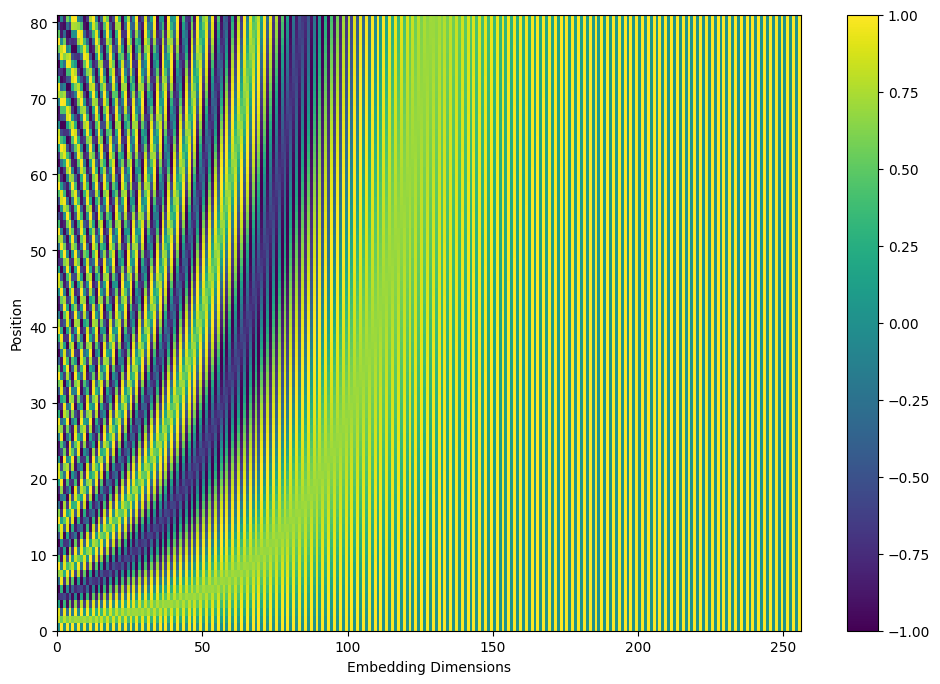

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.pcolormesh(pos_encoding, cmap='viridis')
plt.xlabel('Embedding Dimensions')
plt.xlim((0, emb_dim))
plt.ylabel('Position')
plt.colorbar()
plt.show()

In [81]:
text = "hola mundo!"
tokens = spanish_news_tokenizer(text, max_length=max_len, truncation=True, padding='max_length')
x = torch.tensor(tokens['input_ids']).unsqueeze(0)
mask = torch.tensor(tokens['input_ids']).unsqueeze(0)
embedding = tpe(x)
embedding.shape

torch.Size([1, 81, 256])

## Implementación del Modelo Transformer

Implementaremos la arquitectura del Transformer Encoder desde cero, incluyendo diferentes tipos de positional encoding.

### Positional Encoding

El positional encoding añade información de la posición de los tokens en la secuencia, lo cual es crucial ya que la atención no considera el orden.



In [82]:
class PositionalEncoding(nn.Module):
    """
    Clase para el positional encoding sinusoidal.
    Añade información de la posición a los embeddings de entrada.
    """
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Crear la matriz de positional encoding
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        # Calcular los valores de seno y coseno para las posiciones
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Añade el positional encoding al tensor de entrada.
        Args:
            x: Tensor de entrada (secuencia, batch, d_model)
        """
        # Sumar el positional encoding al embedding
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

class LearnablePositionalEncoding(nn.Module):
    """
    Clase para el positional encoding aprendible.
    Utiliza una capa de embedding para aprender las posiciones.
    """
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        self.pe = nn.Embedding(max_len, d_model)
        self.max_len = max_len

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Añade el positional encoding al tensor de entrada.
        Args:
            x: Tensor de entrada (batch, secuencia, d_model)
        """
        # Crear un tensor de posiciones
        positions = torch.arange(0, x.size(1), device=x.device).unsqueeze(0).expand_as(x[:,:,0])
        # Sumar el embedding de posición al embedding de entrada
        x = x + self.pe(positions)
        return self.dropout(x)

##Módulo de Atención y Bloque del Transformer

Implementamos la atención multi-cabeza y el bloque básico del Transformer Encoder.

In [113]:
#Implementación de Multi-Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model debe ser divisible por num_heads"

        self.d_k = d_model // num_heads # Dimensión de la clave, consulta y valor por cabeza
        self.num_heads = num_heads # Número de cabezas de atención
        self.d_model = d_model  # Dimensión del modelo

        self.wq = nn.Linear(d_model, d_model) # Proyección lineal para las consultas
        self.wk = nn.Linear(d_model, d_model) # Proyección lineal para los valores
        self.wv = nn.Linear(d_model, d_model) # Proyección lineal para las claves

        self.fc = nn.Linear(d_model, d_model)  # Proyección final

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        # Calcula los scores de atención
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Aplica la máscara (para evitar atender a tokens futuros o padding)
        if mask is not None:
            # Expand the mask to be broadcastable with scores
            # Mask shape: (batch_size, sequence_length) -> (batch_size, 1, 1, sequence_length)
            mask = mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask == 0, -1e9)

        # Aplica softmax para obtener las pesos de atención
        attention_weights = F.softmax(scores, dim=-1)

        # Multiplica los pesos por los valores para obtener la salida
        output = torch.matmul(attention_weights, V)

        return output, attention_weights

    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)

        # Proyecta Q, K, V linealmente y divide en múltiples cabezas
        Q = self.wq(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.wk(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.wv(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Calcula la atención para cada cabeza
        attn_output, attention_weights = self.scaled_dot_product_attention(Q, K, V, mask)

        # Concatena las salidas de las cabezas y aplica la capa lineal final
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        output = self.fc(attn_output)

        return output, attention_weights

In [84]:
mha = MultiHeadAttention(emb_dim, num_heads=8)
mha(embedding, embedding, embedding, mask)[0].shape

torch.Size([1, 81, 256])

In [85]:
# 3. Implementación de un bloque Transformer
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads: int = 8, d_ff: int = 512, dropout=0.1):
        super(TransformerBlock, self).__init__()

        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.feed_forward = nn.Sequential(  # Red neuronal feed-forward
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        """
        Paso forward del bloque del encoder.
        Args:
            x: Tensor de entrada (batch, secuencia, d_model)
            mask: Máscara de atención
        """
        # Bloque de atención con conexión residual y normalización
        attn_output, _ = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))

        # Feed-forward con conexión residual
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x


In [86]:
tb = TransformerBlock(emb_dim, num_heads=8, d_ff=512)
tb(embedding, mask).shape

torch.Size([1, 81, 256])

In [110]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from enum import Enum
from typing import Optional, Tuple
from torch.utils.data import Dataset

# Define the PosEncodingType Enum within this cell or ensure it's imported
# Assuming PosEncodingType is defined in a previous cell and accessible
# If not, you might need to define it here or import it correctly.
# For this fix, I will assume PosEncodingType is accessible and convert the string.

# Make sure PosEncodingType is accessible (e.g., defined in an earlier cell)
# from . import PosEncodingType # Example if in a package
# Or redefine if necessary:
class PosEncodingType(Enum):
    SINUSOID = 1
    LEARNABLE = 2


# Clasificador completo de noticias
class SpanishReviewsClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=256, num_heads=8, num_layers=6,
                 num_classes=12, max_length=512, dropout=0.1, pe_type: str = 'sinusoidal'): # Accept string input for pe_type
        super(SpanishReviewsClassifier, self).__init__()

        self.d_model = d_model
        self.max_length = max_length
        self.num_classes = num_classes # Store num_classes
        self.vocab_size = vocab_size # Store vocab_size
        # Assuming tokenizer is accessible globally or passed in init if needed
        # For this fix, we'll get unk_token_id directly from the tokenizer if available,
        # or assume it's 2 based on previous output if tokenizer isn't directly accessible here.
        # A more robust solution would pass tokenizer or unk_token_id to the model's init.
        try:
            # Attempt to get unk_token_id from the global tokenizer if it exists
            self.unk_token_id = tokenizer.unk_token_id
        except NameError:
            # Fallback if tokenizer is not globally accessible, assuming UNK is 2
            # This is less ideal and depends on the specific tokenizer used.
            self.unk_token_id = 2 # Assuming UNK token ID is 2


        # Convert string pe_type to PosEncodingType Enum member
        if isinstance(pe_type, str):
            if pe_type.lower() == 'sinusoidal':
                pe_type_enum = PosEncodingType.SINUSOID
            elif pe_type.lower() == 'learnable':
                pe_type_enum = PosEncodingType.LEARNABLE
            else:
                raise ValueError(f"Unknown positional encoding type string: {pe_type}. Expected 'sinusoidal' or 'learnable'.")
        elif isinstance(pe_type, PosEncodingType):
            pe_type_enum = pe_type
        else:
             raise ValueError(f"Invalid type for pe_type: {type(pe_type)}. Expected string or PosEncodingType.")


        # Embeddings de tokens
        self.token_embedding = nn.Embedding(vocab_size, d_model)

        # Positional Encoding
        if pe_type_enum == PosEncodingType.SINUSOID:
            self.positional_encoding = PositionalEncoding(d_model, dropout=dropout, max_len=max_length)
        elif pe_type_enum == PosEncodingType.LEARNABLE: # Corrected typo here
             # Corrected argument passing to LearnablePositionalEncoding
            self.positional_encoding = LearnablePositionalEncoding(d_model, dropout, max_len=max_length)
        else:
            # This else should theoretically not be reached due to the checks above
            raise ValueError(f"Unknown positional encoding type: {pe_type_enum}")


        # Capas transformer
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_model * 4, dropout)
            for _ in range(num_layers)
        ])

        # Capa de clasificación
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids, attention_mask=None):
        # Ensure input_ids are within the vocabulary range before embedding
        # Replace out-of-range token IDs with UNK token ID
        input_ids = torch.clamp(input_ids, max=self.vocab_size - 1)
        # Alternatively, more explicitly:
        # out_of_range_mask = input_ids >= self.vocab_size
        # input_ids[out_of_range_mask] = self.unk_token_id


        # Embeddings
        x = self.token_embedding(input_ids) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        x = self.dropout(x)

        # Pasar por las capas transformer
        for transformer in self.transformer_blocks:
            x = transformer(x, attention_mask)

        # Pooling: usar el token [CLS] o promedio
        if attention_mask is not None:
            # Promedio ponderado por la máscara de atención
            mask_expanded = attention_mask.unsqueeze(-1).expand(x.size()).float()
            sum_embeddings = torch.sum(x * mask_expanded, dim=1)
            sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
            pooled = sum_embeddings / sum_mask
        else:
            # Promedio simple
            pooled = x.mean(dim=1)

        # Clasificación
        logits = self.classifier(pooled)
        return logits

In [88]:
    # Preparar datos
    # Correctly pair combined texts with labels
    texts = [f"{dataset['review_title'][i]} {dataset['review_body'][i]}" for i in range(1000)] # Combine title and body for first 1000 entries
    categories = dataset['stars'] # Take stars for the first 1000 entries

##Visualización del Positional Encoding

Visualizamos los vectores de positional encoding para entender cómo capturan la información de la posición.

Visualizando el Positional Encoding Sinusoidal:


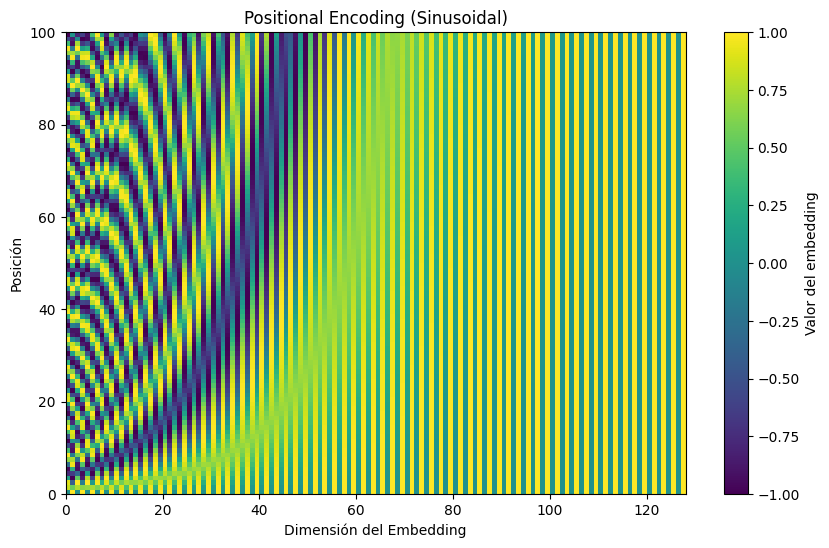

Visualizando el Positional Encoding Aprendible:


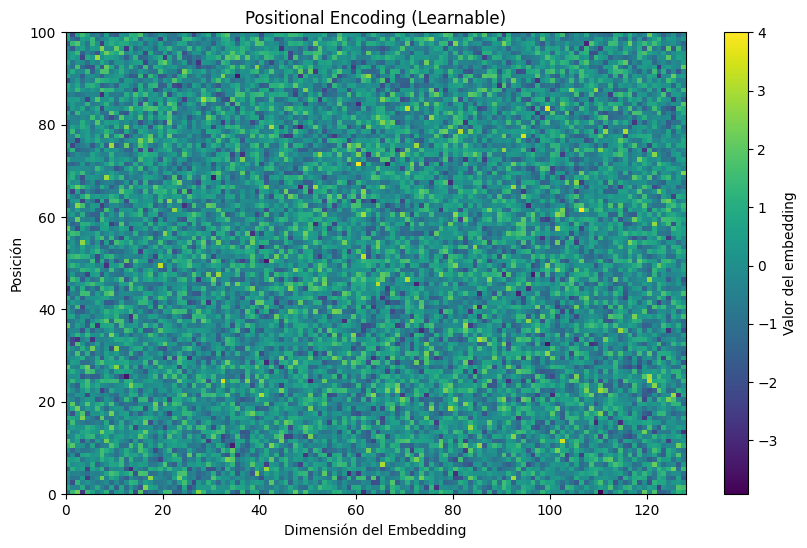

In [89]:
# Visualización del positional encoding
def visualize_positional_encoding(max_len, d_model, pe_type):
    if pe_type == 'sinusoidal':
        pe_module = PositionalEncoding(d_model, max_len=max_len)
        pe_tensor = pe_module.pe.squeeze(1).detach().numpy()
    elif pe_type == 'learnable':
        pe_module = LearnablePositionalEncoding(d_model, max_len=max_len)
        pe_tensor = pe_module.pe.weight.detach().numpy()

    plt.figure(figsize=(10, 6))
    plt.pcolormesh(pe_tensor, cmap='viridis')
    plt.xlabel('Dimensión del Embedding')
    plt.ylabel('Posición')
    plt.title(f'Positional Encoding ({pe_type.capitalize()})')
    plt.colorbar(label='Valor del embedding')
    plt.show()

# Parámetros para la visualización
d_model_vis = 128
max_len_vis = 100

print("Visualizando el Positional Encoding Sinusoidal:")
visualize_positional_encoding(max_len_vis, d_model_vis, 'sinusoidal')

print("Visualizando el Positional Encoding Aprendible:")
visualize_positional_encoding(max_len_vis, d_model_vis, 'learnable')


In [90]:
# Convertir categorías a números
unique_categories = list(set(categories))
category_to_id = {cat: idx for idx, cat in enumerate(unique_categories)}
labels = [category_to_id[cat] for cat in categories]

print(f"Categorías encontradas: {unique_categories}")
print(f"Número de clases: {len(unique_categories)}")


Categorías encontradas: [1, 2, 3, 4, 5]
Número de clases: 5


## Búsqueda de Hiperparámetros con Optuna 🔍
Utilizaremos Optuna para encontrar la mejor combinación de hiperparámetros que optimice el rendimiento del modelo.

## Función de Entrenamiento y Evaluación
Definimos la lógica para entrenar y evaluar el modelo en cada trial de Optuna

In [111]:
from sklearn.metrics import accuracy_score # Import accuracy_score
from sklearn.metrics import f1_score, classification_report # Import for evaluation metrics

def train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, epochs, scheduler=None):
    """
    Función para entrenar y evaluar un modelo.
    Devuelve la precisión en el conjunto de validación.
    """
    best_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            # Move batch to device
            batch = {k: v.to(device) for k, v in batch.items()}

            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['y'] # Corrected label key

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Evaluación en el conjunto de validación
        model.eval()
        val_preds = []
        val_true = []
        with torch.no_grad():
            for batch in val_loader:
                 # Move batch to device
                batch = {k: v.to(device) for k, v in batch.items()}

                input_ids = batch['input_ids']
                attention_mask = batch['attention_mask']
                labels = batch['y'] # Corrected label key

                outputs = model(input_ids, attention_mask)
                _, preds = torch.max(outputs, dim=1)

                val_preds.extend(preds.cpu().tolist())
                val_true.extend(labels.cpu().tolist()) # Corrected label key

        val_acc = accuracy_score(val_true, val_preds)

        # Guardar el mejor modelo
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = model.state_dict()

        # Ajustar la tasa de aprendizaje si se usa el scheduler
        if scheduler:
            scheduler.step(val_acc)

    return best_acc, best_model_state

## Función Objetivo para Optuna
Esta es la función principal que Optuna llamará para cada trial.



In [ ]:
def objective(trial):
    """
    Función objetivo para la optimización de hiperparámetros con Optuna.
    Args:
        trial: Objeto de Optuna que gestiona los hiperparámetros.
    """
    # Definición de los hiperparámetros a optimizar
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-3)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    n_layers = trial.suggest_int('n_layers', 2, 6)
    n_heads = trial.suggest_categorical('n_heads', [4, 8, 12])
    dropout = trial.suggest_uniform('dropout', 0.1, 0.5)
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-4)
    d_model = trial.suggest_categorical('d_model', [128, 256, 512]) # Dimensión del embedding
    pe_type = trial.suggest_categorical('pe_type', ['sinusoidal', 'learnable'])
    epochs = 5 # Usar un número pequeño para la búsqueda rápida

    # Check if d_model is divisible by num_heads, prune trial if not
    if d_model % n_heads != 0:
        raise optuna.exceptions.TrialPruned("d_model must be divisible by num_heads")


    # Inicializar el modelo con los hiperparámetros sugeridos
    model = SpanishReviewsClassifier(
        vocab_size=len(tokenizer),
        d_model=d_model,
        max_length=max_len, # Corrected keyword argument name
        num_layers=n_layers, # Corrected parameter name from n_layers to num_layers
        num_heads=n_heads,   # Corrected parameter name from n_heads to num_heads
        dropout=dropout,
        num_classes=5, # Corrected number of classes to 5
        pe_type=pe_type
    ).to(device)

    # Definir el optimizador y el criterio de pérdida
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    # Usar un scheduler para reducir la tasa de aprendizaje
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 'max', patience=2, factor=0.5
    )

    # Entrenar y evaluar el modelo
    accuracy, _ = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, epochs, scheduler)

    # Devolver la métrica a optimizar (precisión en validación)
    return accuracy

# Ejecutar la optimización
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\nMejores hiperparámetros:")
print(study.best_params)
print("\nMejor precisión en validación:")
print(study.best_value)

[I 2025-08-31 02:25:18,398] A new study created in memory with name: no-name-f31a57e2-a316-423a-b765-dc239e2604f5


  0%|          | 0/50 [00:00<?, ?it/s]

## Evaluación del Mejor Modelo 🏆
Una vez que Optuna ha terminado, entrenamos el mejor modelo encontrado y lo evaluamos en el conjunto de prueba.



In [ ]:
# Obtener los mejores hiperparámetros
best_params = study.best_params
best_accuracy = study.best_value

# Definir los parámetros para el entrenamiento final
final_epochs = 10 # Más epochs para el entrenamiento final
best_batch_size = best_params['batch_size']

# Crear DataLoaders para el entrenamiento y prueba final
train_loader_final = create_data_loader(df_train, tokenizer, max_len, best_batch_size)
test_loader_final = create_data_loader(df_test, tokenizer, max_len, best_batch_size)

# Inicializar y entrenar el modelo final
best_model = SentimentClassifier(
    vocab_size=len(tokenizer),
    d_model=best_params['d_model'],
    max_len=max_len,
    n_layers=best_params['n_layers'],
    n_heads=best_params['n_heads'],
    dropout=best_params['dropout'],
    n_classes=3,
    pe_type=best_params['pe_type']
).to(device)

optimizer_final = torch.optim.Adam(best_model.parameters(), lr=best_params['learning_rate'], weight_decay=best_params['weight_decay'])
criterion_final = nn.CrossEntropyLoss()
scheduler_final = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_final, 'max', patience=2, factor=0.5
)

# Entrenar y guardar el mejor estado del modelo
_, best_model_state = train_and_evaluate(best_model, train_loader_final, test_loader_final, optimizer_final, criterion_final, final_epochs, scheduler_final)
best_model.load_state_dict(best_model_state)

# Evaluación en el conjunto de prueba
def evaluate_model(model, data_loader):
    """
    Función para evaluar el modelo en un conjunto de datos.
    """
    model.eval()
    all_preds = []
    all_true = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            sentiments = batch['sentiment'].to(device)

            outputs = model(input_ids, attention_mask)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().tolist())
            all_true.extend(sentiments.cpu().tolist())

    return all_true, all_preds

true_labels, predicted_labels = evaluate_model(best_model, test_loader_final)

# Calcular métricas de rendimiento
test_accuracy = accuracy_score(true_labels, predicted_labels)
test_f1 = f1_score(true_labels, predicted_labels, average='weighted')
report = classification_report(true_labels, predicted_labels)

print("\n--- Resultados de la Evaluación en el Conjunto de Prueba ---")
print(f"Precisión (Accuracy): {test_accuracy:.4f}")
print(f"Puntuación F1 (Weighted): {test_f1:.4f}")
print("\nInforme de Clasificación:\n", report)

# Opcional: Guardar el mejor modelo
torch.save(best_model.state_dict(), 'best_sentiment_classifier.pt')
print("Modelo guardado exitosamente.")
